# Callbacks

> Event handlers

In [ ]:
#| default_exp callbacks

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
from fastai.callback.training import ShortEpochCallback, GradientAccumulation
from fastai.callback.tracker import  EarlyStoppingCallback, SaveModelCallback, ReduceLROnPlateau, ShowGraphCallback
from fastai.callback.schedule import ParamScheduler, SchedCos, SchedExp, SchedLin, SchedNo
from fastai.callback.core import Callback, range_of, Tensor
from fastai.vision.all import CSVLogger
import matplotlib.pyplot as plt


## Training Callbacks

Callbacks that add functionlities during the training phase, including Callbacks that make decisions depending how a monitored metric/loss behaves

In [ ]:
#| export
class MeanLossGraphCallback(Callback):
    "Update a graph of training and validation loss"
    order,run_valid=65,False

    def before_fit(self):
        self.run = not hasattr(self.learn, 'lr_finder') and not hasattr(self, "gather_preds")
        if not(self.run): return
        self.nb_batches = []
        self.train_losses = []
        assert hasattr(self.learn, 'progress')

    def after_train(self): 
        self.nb_batches.append(self.train_iter)

    def after_epoch(self):
        "Plot validation loss in the pbar graph"
        if not self.nb_batches: return
        rec = self.learn.recorder
        epochs = range(len(self.nb_batches)) + 1
        self.train_losses.append(rec.log[1])
        val_losses = [v[1] for v in rec.values]
        x_bounds = (0, self.n_epoch)
        y_bounds = (0, max((max(Tensor(rec.losses)), max(Tensor(val_losses)))))
        self.progress.mbar.update_graph([(epochs, self.train_losses), (epochs, val_losses)], x_bounds, y_bounds)


In [ ]:
show_doc(ShortEpochCallback)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/training.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### ShortEpochCallback

```python

def ShortEpochCallback(
    pct:float=0.01, short_valid:bool=True
):


```

*Fit just `pct` of an epoch, then stop*

In [ ]:
#| export
ShortEpochCallback = ShortEpochCallback

In [ ]:
show_doc(GradientAccumulation)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/training.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### GradientAccumulation

```python

def GradientAccumulation(
    n_acc:int=32
):


```

*Accumulate gradients before updating weights*

In [ ]:
#| export
GradientAccumulation = GradientAccumulation

In [ ]:
show_doc(EarlyStoppingCallback)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/tracker.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### EarlyStoppingCallback

```python

def EarlyStoppingCallback(
    monitor:str='valid_loss', # value (usually loss or metric) being monitored.
    comp:NoneType=None, # numpy comparison operator; np.less if monitor is loss, np.greater if monitor is metric.
    min_delta:float=0.0, # minimum delta between the last monitor value and the best monitor value.
    patience:int=1, # number of epochs to wait when training has not improved model.
    reset_on_fit:bool=True, # before model fitting, reset value being monitored to -infinity (if monitor is metric) or +infinity (if monitor is loss).
):


```

*A `TrackerCallback` that terminates training when monitored quantity stops improving.*

In [ ]:
#| export
EarlyStoppingCallback = EarlyStoppingCallback

In [ ]:
show_doc(SaveModelCallback)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/tracker.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### SaveModelCallback

```python

def SaveModelCallback(
    monitor:str='valid_loss', # value (usually loss or metric) being monitored.
    comp:NoneType=None, # numpy comparison operator; np.less if monitor is loss, np.greater if monitor is metric.
    min_delta:float=0.0, # minimum delta between the last monitor value and the best monitor value.
    fname:str='model', # model name to be used when saving model.
    every_epoch:bool=False, # if true, save model after every epoch; else save only when model is better than existing best.
    at_end:bool=False, # if true, save model when training ends; else load best model if there is only one saved model.
    with_opt:bool=False, # if true, save optimizer state (if any available) when saving model.
    reset_on_fit:bool=True, # before model fitting, reset value being monitored to -infinity (if monitor is metric) or +infinity (if monitor is loss).
):


```

*A `TrackerCallback` that saves the model's best during training and loads it at the end.*

In [ ]:
#| export
SaveModelCallback = SaveModelCallback

In [ ]:
show_doc(ReduceLROnPlateau)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/tracker.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### ReduceLROnPlateau

```python

def ReduceLROnPlateau(
    monitor:str='valid_loss', # value (usually loss or metric) being monitored.
    comp:NoneType=None, # numpy comparison operator; np.less if monitor is loss, np.greater if monitor is metric.
    min_delta:float=0.0, # minimum delta between the last monitor value and the best monitor value.
    patience:int=1, # number of epochs to wait when training has not improved model.
    factor:float=10.0, # the denominator to divide the learning rate by, when reducing the learning rate.
    min_lr:int=0, # the minimum learning rate allowed; learning rate cannot be reduced below this minimum.
    reset_on_fit:bool=True, # before model fitting, reset value being monitored to -infinity (if monitor is metric) or +infinity (if monitor is loss).
):


```

*A `TrackerCallback` that reduces learning rate when a metric has stopped improving.*

In [ ]:
#| export
ReduceLROnPlateau = ReduceLROnPlateau

## Loggers

The `ShowGraphCallback` is a convenient callback for visualizing training progress. By plotting the training and validation loss, it helps users monitor convergence and performance, making it easy to assess if the model requires adjustments in learning rate, architecture, or data handling.


In [ ]:
show_doc(ShowGraphCallback)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/progress.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### ShowGraphCallback

```python

def ShowGraphCallback(
    after_create:NoneType=None, before_fit:NoneType=None, before_epoch:NoneType=None, before_train:NoneType=None,
    before_batch:NoneType=None, after_pred:NoneType=None, after_loss:NoneType=None, before_backward:NoneType=None,
    after_cancel_backward:NoneType=None, after_backward:NoneType=None, before_step:NoneType=None,
    after_cancel_step:NoneType=None, after_step:NoneType=None, after_cancel_batch:NoneType=None,
    after_batch:NoneType=None, after_cancel_train:NoneType=None, after_train:NoneType=None,
    before_validate:NoneType=None, after_cancel_validate:NoneType=None, after_validate:NoneType=None,
    after_cancel_epoch:NoneType=None, after_epoch:NoneType=None, after_cancel_fit:NoneType=None,
    after_fit:NoneType=None
):


```

*Update a graph of training and validation loss*

In [ ]:
#| export
ShowGraphCallback = ShowGraphCallback

In [ ]:
from fastai.test_utils import synth_learner
import matplotlib.pyplot as plt

epoch,train_loss,valid_loss,time
0,10.285473,8.976877,00:00
1,8.909032,6.201019,00:00
2,7.382292,3.919028,00:00
3,5.993356,2.323699,00:00
4,4.801883,1.363611,00:00


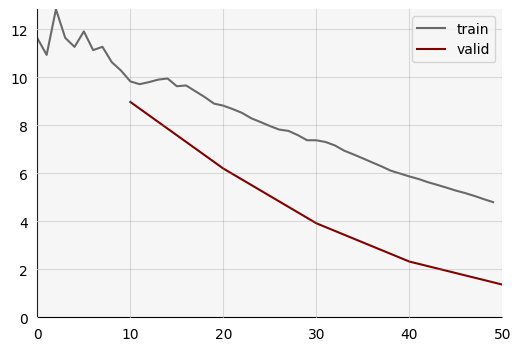

In [ ]:
# Set global parameters
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'text.color': 'black',
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.titlesize': 16,
    'axes.grid': True,
    'axes.axisbelow': False,
    'grid.alpha': 0.25,
    'grid.linestyle': '-',
    'grid.color' : 'gray',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,  
    'figure.facecolor': 'white',
    'axes.facecolor': '#f7f6f6',
    'savefig.facecolor': 'white',
    'lines.color': 'black',
    'axes.prop_cycle': plt.cycler('color', ['dimgray', 'maroon', 'teal', '#102e42', "goldenrod", 'darkslateblue', '#1c5175', 'cadetblue','steelblue'])
})

# plt.style.use('petroff10')
learn = synth_learner(cbs=ShowGraphCallback())
learn.fit(5)

The `CSVLogger` is a tool for logging model training metrics to a CSV file, offering a permanent record of training history. This feature is especially useful for long-term experiments and fine-tuning, allowing you to track and analyze model performance over time.


In [ ]:
show_doc(CSVLogger)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/progress.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### CSVLogger

```python

def CSVLogger(
    fname:str='history.csv', append:bool=False
):


```

*Log the results displayed in `learn.path/fname`*

In [ ]:
#| export
CSVLogger = CSVLogger

## Schedulers

Callback and helper functions to schedule hyper-parameters

In [ ]:
show_doc(ParamScheduler)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/schedule.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### ParamScheduler

```python

def ParamScheduler(
    scheds
):


```

*Schedule hyper-parameters according to `scheds`*

In [ ]:
#| export
ParamScheduler = ParamScheduler

`scheds` is a dictionary with one key for each hyper-parameter you want to schedule, with either a scheduler or a list of schedulers as values (in the second case, the list must have the same length as the the number of parameters groups of the optimizer).

In [ ]:
show_doc(SchedCos)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/schedule.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### SchedCos

```python

def SchedCos(
    start, end
):


```

*Cosine schedule function from `start` to `end`*

In [ ]:
#| export
SchedCos = SchedCos

In [ ]:
show_doc(SchedExp)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/schedule.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### SchedExp

```python

def SchedExp(
    start, end
):


```

*Exponential schedule function from `start` to `end`*

In [ ]:
#| export
SchedExp = SchedExp

In [ ]:
show_doc(SchedLin)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/schedule.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### SchedLin

```python

def SchedLin(
    start, end
):


```

*Linear schedule function from `start` to `end`*

In [ ]:
#| export
SchedLin = SchedLin

In [ ]:
show_doc(SchedNo)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/schedule.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### SchedNo

```python

def SchedNo(
    start, end
):


```

*Constant schedule function with `start` value*

In [ ]:
#| export
SchedNo = SchedNo

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()